In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Loading Churn Dataset...")
df = pd.read_csv("Churn_Modelling.csv")

columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

print("\n--- Dataset Info ---")
print(df.head(2))

Loading Churn Dataset...

--- Dataset Info ---
   CreditScore Geography  Gender  Age  Tenure   Balance  NumOfProducts  \
0          619    France  Female   42       2      0.00              1   
1          608     Spain  Female   41       1  83807.86              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  


In [2]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

print("--- Encoded Columns Preview ---")
print(df.head(2))

--- Encoded Columns Preview ---
   CreditScore  Age  Tenure   Balance  NumOfProducts  HasCrCard  \
0          619   42       2      0.00              1          1   
1          608   41       1  83807.86              1          0   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1              False   
1               1        112542.58       0              False   

   Geography_Spain  Gender_Male  
0            False        False  
1             True        False  


In [3]:
X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Train set size: 8000 samples
Test set size: 2000 samples


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Complete!")

Scaling Complete!


RANDOM FOREST

In [5]:
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

rf_preds = rf_model.predict(X_test_scaled)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}")

Training Random Forest Classifier...
Random Forest Accuracy: 0.8610


GRADIENT BOOSTING CLASSIFIER

In [6]:
print("Training Gradient Boosting Classifier...")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)

gb_preds = gb_model.predict(X_test_scaled)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, gb_preds):.4f}")

Training Gradient Boosting Classifier...
Gradient Boosting Accuracy: 0.8700



 FINAL MODEL RESULTS 

Confusion Matrix:
 [[1541   52]
 [ 208  199]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000


--- Top 5 Factors Driving Customer Churn ---
          Feature  Importance
              Age    0.388266
    NumOfProducts    0.299886
   IsActiveMember    0.113922
          Balance    0.089055
Geography_Germany    0.055562


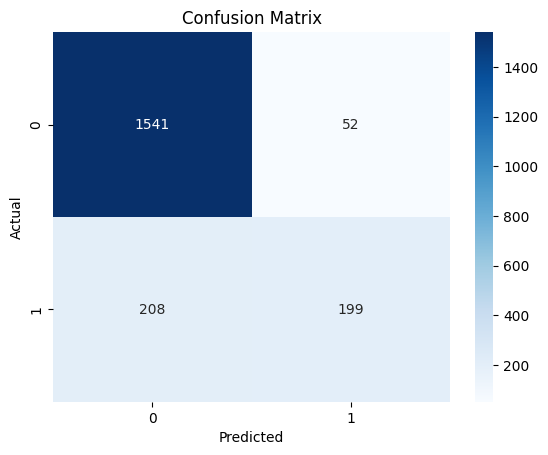

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
print("\n FINAL MODEL RESULTS ")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, gb_preds))
print("\nClassification Report:\n", classification_report(y_test, gb_preds))

importances = gb_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\n Top 5 Factors Driving Customer Churn ")
print(feature_imp_df.head(5).to_string(index=False))

sns.heatmap(confusion_matrix(y_test, gb_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
